Supervised Learning PA - Python - 5/2/2026 - derave1577

In [1]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "derave1577"
# Load the Census dataset
data = pd.read_csv('census_income_dataset.csv')
# Convert the income feature to binary
data['income'] = data['income'].str.strip()
data['income'] = data['income'].apply(lambda x: 1 if x == '>50K' else 0)
# Display the first few rows to understand what the data looks like
display(Markdown("### Step 1: Load the Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
display(data.head())
# Get a concise summary of the DataFrame
print(data.info())
# Get descriptive statistics that summarize the central tendency,
# dispersion, and shape of the dataset's numerical features
display(data.describe())

### Step 1: Load the Dataset

Date: 2026-05-02

Student ID: derave1577

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  int64
dtypes: int64(7), str(8)
memory usage: 5.6 MB
None


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382,0.160538
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444,0.367108
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [2]:
display(Markdown("### Step 2: Data Cleaning"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Remove duplicates in the dataset
data = data.drop_duplicates().reset_index(drop=True)
# Check for missing values in the dataset
missing_values = data.isnull().sum()
print(f"Missing values in each column:\n{missing_values}")
numerical_cols = data.select_dtypes(include=['number']).columns
data[numerical_cols] = data[numerical_cols].fillna(data[numerical_cols].median())
# Verify that there are no remaining missing values
missing_values_after = data.isnull().sum()
print(f"Missing values after cleaning:\n{missing_values_after}")
from sklearn.preprocessing import OneHotEncoder
display(Markdown("### Step 3: Encoding Categorical Variables"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Initialize the OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first')
# Select categorical variables for encoding
categorical_features = data.select_dtypes(exclude=['number']).columns.tolist()
# Apply one-hot encoding
encoded_features = encoder.fit_transform(data[categorical_features])
# Convert the encoded features into a DataFrame
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features))

# Drop original categorical columns and concatenate encoded features
data = data.drop(columns=categorical_features)
encoded_df = encoded_df.reset_index(drop=True)
data = pd.concat([data, encoded_df], axis=1)

from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
display(Markdown("### Step 4: Scaling Numerical Features"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Initialize the StandardScaler
scaler = StandardScaler()
# Select numerical features for scaling
numerical_features = data.select_dtypes(include=['number']).columns.tolist()
if 'income' in numerical_features:
    numerical_features.remove('income')
# Apply scaling
scaled_data = data.copy()
scaled_data[numerical_features] = scaler.fit_transform(data[numerical_features])
# Calculate z-scores for the scaled numerical features
for feature in numerical_features:
    scaled_data[f'{feature}_Z'] = zscore(scaled_data[feature])
# Remove outliers based on z-scores outside the range [-2, 2]
for feature in numerical_features:
    scaled_data = scaled_data[(scaled_data[f'{feature}_Z'] >= -2) & (scaled_data[f'{feature}_Z'] <= 2)]
# Drop the z-score columns as they are no longer needed
scaled_data = scaled_data.drop(columns=[f'{feature}_Z' for feature in numerical_features])
# Recalculate the scaling on the cleaned data
scaled_data[numerical_features] = scaler.fit_transform(scaled_data[numerical_features])
# Display the first few rows to verify the changes
display(scaled_data.head())

### Step 2: Data Cleaning

Date: 2026-05-02

Student ID: derave1577

Missing values in each column:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64
Missing values after cleaning:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64


### Step 3: Encoding Categorical Variables

...

Student ID: derave1577

### Step 4: Scaling Numerical Features

Date: 2026-05-02

Student ID: derave1577

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_nan
128,-0.669541,-0.578140,-0.135250,-0.216952,0.0,0.297964,0,-2.775558e-17,-1.110223e-16,3.469447e-18,...,1.387779e-17,0.0,0.0,0.0,0.0,3.469447e-18,-5.551115e-17,-1.387779e-17,0.0,-1.387779e-17
149,-0.169825,-0.044519,0.909439,-0.216952,0.0,0.297964,0,-2.775558e-17,-1.110223e-16,3.469447e-18,...,1.387779e-17,0.0,0.0,0.0,0.0,3.469447e-18,-5.551115e-17,-1.387779e-17,0.0,-1.387779e-17
154,0.392355,0.875978,-0.135250,-0.216952,0.0,0.869402,1,-2.775558e-17,-1.110223e-16,3.469447e-18,...,1.387779e-17,0.0,0.0,0.0,0.0,3.469447e-18,-5.551115e-17,-1.387779e-17,0.0,-1.387779e-17
459,-0.856934,-0.737672,0.909439,-0.216952,0.0,0.297964,0,-2.775558e-17,-1.110223e-16,3.469447e-18,...,1.387779e-17,0.0,0.0,0.0,0.0,3.469447e-18,-5.551115e-17,-1.387779e-17,0.0,-1.387779e-17
580,1.204393,0.203379,0.909439,-0.216952,0.0,-0.844912,1,-2.775558e-17,-1.110223e-16,3.469447e-18,...,1.387779e-17,0.0,0.0,0.0,0.0,3.469447e-18,-5.551115e-17,-1.387779e-17,0.0,-1.387779e-17


In [3]:
from sklearn.model_selection import train_test_split
print(data['income'].value_counts())
display(Markdown("### Step 4: Splitting the Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Update the main dataframe to use scaled features
data = scaled_data
# Preparing features (X) and target variable (y) from the prepared dataset
X = data.drop('income', axis=1)
y = data['income']
# Splitting the data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, stratify=y, random_state=42)
# Display the sizes of the training and test sets to verify the split
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

income
0    40956
1     7839
Name: count, dtype: int64


### Step 4: Splitting the Data

Date: 2026-05-02

Student ID: derave1577

Training set size: 156 samples
Test set size: 68 samples


### Step 5: K-Nearest Neighbor

Date: 2026-05-02

Student ID: derave1577

Classification Report for KNN:
income
0    58
1    10
Name: count, dtype: int64
              precision    recall  f1-score   support

       <=50k       0.90      0.97      0.93        58
        >50k       0.67      0.40      0.50        10

    accuracy                           0.88        68
   macro avg       0.78      0.68      0.72        68
weighted avg       0.87      0.88      0.87        68



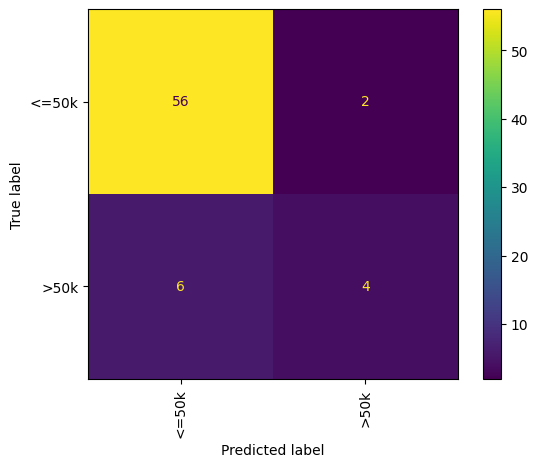

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
display(Markdown("### Step 5: K-Nearest Neighbor"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
# Make predictions on the test set
y_pred_knn = knn.predict(X_test)
target_names = ['<=50k', '>50k']
# Evaluate the model
print("Classification Report for KNN:")
print(y_test.value_counts())
print(classification_report(y_test, y_pred_knn, target_names=target_names))
# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, display_labels=target_names, xticks_rotation='vertical')
plt.show()

### Step 6: Hyperparameter Tuning for KNN

Date: 2026-05-02

Student ID: derave1577

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=3, weights=uniform; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ..metric=euclidean, n_neighbors=3, weights=distance; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=4, weights=uniform; total time=   0.0s
[CV] END ...metric=euclidean, n_neighbors=4, wei

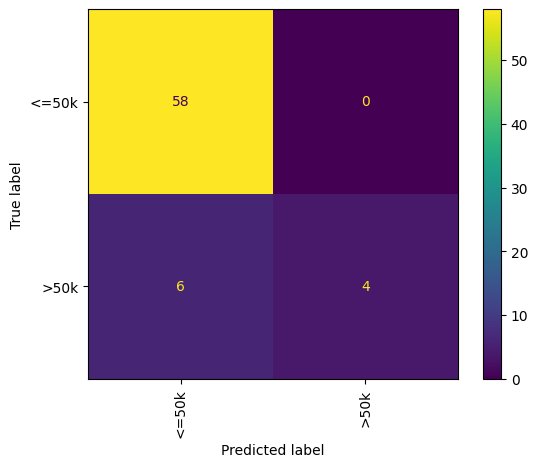

In [6]:
from sklearn.model_selection import GridSearchCV
display(Markdown("### Step 6: Hyperparameter Tuning for KNN"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Define the parameter grid for hyperparameter tuning
param_grid = {'n_neighbors': [3, 4], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhatten', 'minkowski']}
# Initialize GridSearchCV with the KNN model and parameter grid
grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid, refit=True, verbose=2, cv=5)
# Fit the model to the training data
grid_search_knn.fit(X_train, y_train)
# Display the best parameters and best score
print(f"Best Parameters: {grid_search_knn.best_params_}")
print(f"Best Score: {grid_search_knn.best_score_}")
# Make predictions with the best estimator
y_pred_knn_tuned = grid_search_knn.best_estimator_.predict(X_test)
# Evaluate the tuned model
print("Classification Report for Tuned KNN:")
print(classification_report(y_test, y_pred_knn_tuned, target_names=target_names))
# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_tuned, display_labels=target_names, xticks_rotation='vertical')
plt.show()

### Step 7: Visualizing the Tuned KNN Precision and Recall

Date: 2026-05-02

Student ID: derave1577

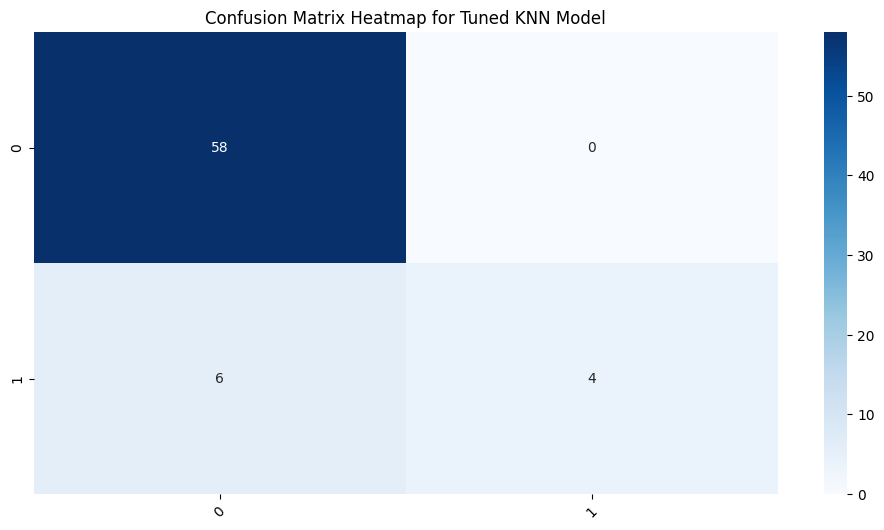

In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
display(Markdown("### Step 7: Visualizing the Tuned KNN Precision and Recall"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_knn_tuned)
# Plot precision and recall
plt.figure(figsize=(12, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap for Tuned KNN Model')
plt.xticks(rotation=45)
plt.show()

### Step 8: Calculating and Plotting the ROC and AUC

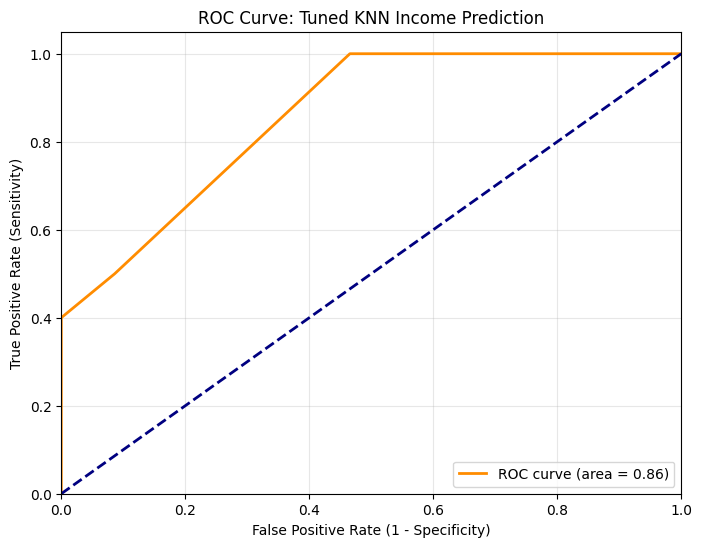

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
display(Markdown("### Step 8: Calculating and Plotting the ROC and AUC"))

# Get probabilities for the positive class (index 1 is '>50k')
y_pred_proba = grid_search_knn.best_estimator_.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC (No loop needed for binary!)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal dashed line

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve: Tuned KNN Income Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
